# DESI QSO Simulations

In [1]:
import fitsio
import numpy as np
import healpy as hp
import pandas as pd
import seaborn as sns
from astropy.table import Table, vstack, MaskedColumn
import matplotlib.pyplot as plt
%matplotlib inline

from Simulation.simulMap import *
from Simulation.fitMap import *
from Simulation.lumMag_sampling import *
from Simulation.mappers import DensityMapper, FracCovMapper

In [2]:
nside = 128
npix= hp.nside2npix(nside)
area_deg2 = hp.nside2pixarea(nside, degrees=True)
print("Number of pixels = {}".format(npix))
print("Surface of a pixel = {} deg^2".format(area_deg2))

Number of pixels = 196608
Surface of a pixel = 0.2098234113027917 deg^2


## FRACCOV

Saving DESI_DR1_QSO_Density_map_FRACCOV in data/Data DESI/DESI Figures/DESI DR1 QSO/DESI_DR1_QSO_Data/DESI_DR1_QSO_Density_map_FRACCOV.pdf


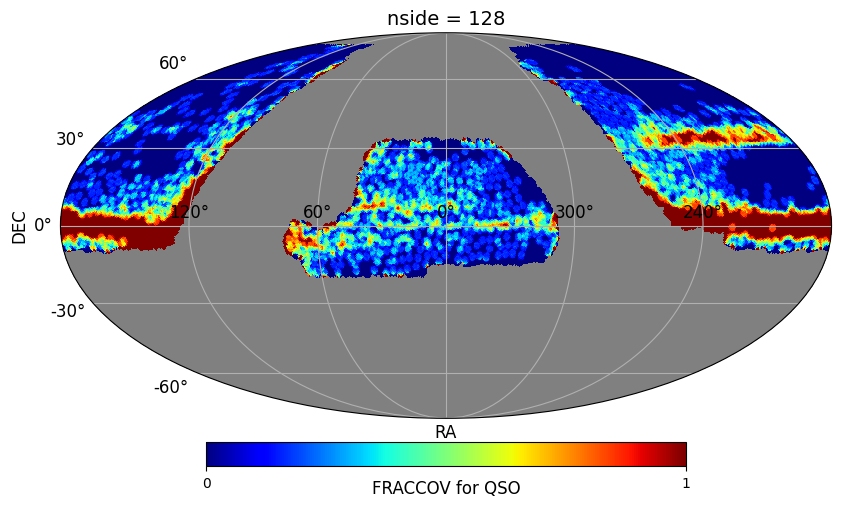

In [10]:
#File name:
DIR = "data/Data DESI/"
FILE_DR1 = DIR + "dr1-main-dark.fits"

outputDIR = DIR + "DESI Figures/DESI DR1 QSO/" #to save figures
output_path_QSO = outputDIR + "DESI_DR1_QSO_Data/" #common suffix to every figures
output_path_Simu = outputDIR + "DESI_DR1_QSO_Simul/"
suffix_QSO = "DESI_DR1_QSO_Density_map_"
suffix_Simu = "DESI_DR1_QSO_Simul_Density_map_"

#Reading file:
DR1_Mapper = FracCovMapper.read(FILE_DR1, nest=True)
DR1_Mapper.get_nside(nside)
DR1_Mapper._set_suffixTextPlot(unit = "QSO") #to customize the unit of plots.
DR1_Mapper.plot(use_map = "nside", title = f"nside = {DR1_Mapper.nside}")

## Density

### From DESI data

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.492e+06 (χ²/ndof = 12.7) │              Nfcn = 359              │
│ EDM = 1.23e-05 (Goal: 0.0002)    │           time = 10.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │   79.93   │   0.05    │   -0.05    │    0.05    │    0    │         │       │
│ 1 │ A    │  0.6125   │  0.0013   │  -0.0013   │   0.0013   │    0    │    1    │       │
│ 2 │ ra   │  186.22   │   0.24    │   -0.24    │    0.24    │    0    │   360   │       │
│ 3 │ dec  │  -70.06   │   0.06    │   -0.06    │    0.06    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.05   │   0.05    │  -0.0013  │  0.0013   │   -0.24   │   0.24    │   -0.06   │   0.06    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │        M        A       ra      dec │
├─────┼─────────────────────────────────────┤
│   M │   0.0027  34.1e-6   0.0005  -0.0009 │
│   A │  34.1e-6 1.62e-06  38.9e-6 -18.4e-6 │
│  ra │   0.0005  38.9e-6   0.0571   -0.000 │
│ dec │  -0.0009 -18.4e-6   -0.000   0.0039 │
└─────┴─────────────────────────────────────┘

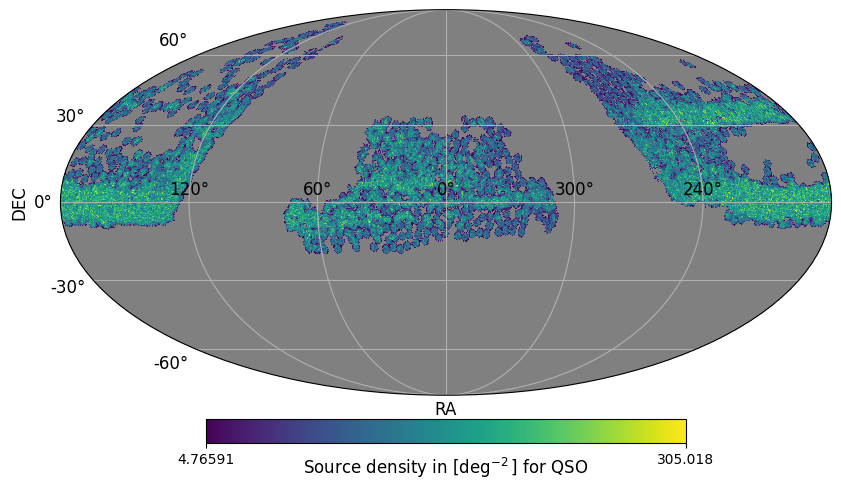

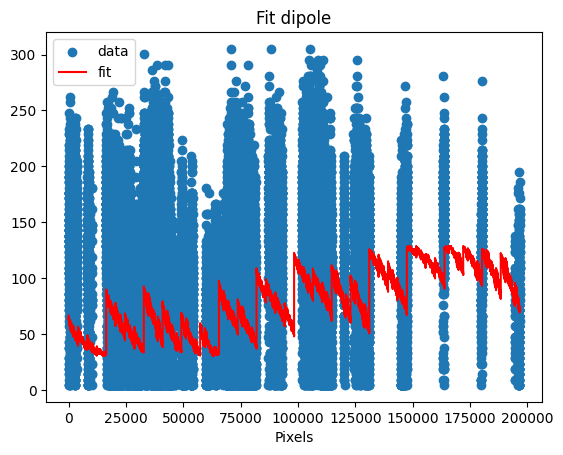

In [4]:
#File names:
FILE_NGC = DIR + "QSO_NGC_clustering.dat.fits"
FILE_SGC = DIR + "QSO_SGC_clustering.dat.fits"

#Reading files:
NGC_Mapper = DensityMapper.read(FILE_NGC, nside=nside, nest=True)
SGC_Mapper = DensityMapper.read(FILE_SGC, nside=nside, nest=True)
ALL_Mapper = NGC_Mapper.add(SGC_Mapper)
ALL_Mapper._set_suffixTextPlot(unit = "QSO") #to customize the unit of plots.
ALL_Mapper.set_mask()
# ALL_Mapper.plot("Masked")
# get_savefig(plt, output_path_QSO, suffix_QSO+"mask0");

#Fitting dipole:
init =  (200, 1, 100, 40)
m = ALL_Mapper.fit_dipole("Masked", init)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 7.843e+05 (χ²/ndof = 4.0)  │              Nfcn = 795              │
│ EDM = 5.49e-05 (Goal: 0.0002)    │           time = 24.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  114.060  │   0.030   │   -0.031   │   0.031    │    0    │         │       │
│ 1 │ A    │ 404.7e-3  │  0.6e-3   │  -0.6e-3   │   0.6e-3   │    0    │    1    │       │
│ 2 │ ra   │  0.6e-6   │328220638.5e-6│  -0.6e-6   │359999999.4e-6│    0    │   360   │       │
│ 3 │ dec  │-89.99999999977│0.01791963718│-0.00000000023│0.01791963718│   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.030   │   0.031   │  -0.6e-3  │  0.6e-3   │  -0.6e-6  │359999999.4e-6│ -0.23e-9  │17919637.18e-9│
│  Valid   │   False   │   False   │   False   │   False   │   True    │   True    │   True    │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   True    │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   True    │   True    │   False   │   False   │   False   │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────┐
│     │               M               A              ra             dec │
├─────┼─────────────────────────────────────────────────────────────────┤
│   M │        0.000933          1.4e-6               0              -0 │
│   A │          1.4e-6        4.16e-07       -170.2e-6        0.002e-9 │
│  ra │               0       -170.2e-6         2.1e+05 -1.869936526e-3 │
│ dec │              -0        0.002e-9 -1.869936526e-3        1.67e-11 │
└─────┴─────────────────────────────────────────────────────────────────┘

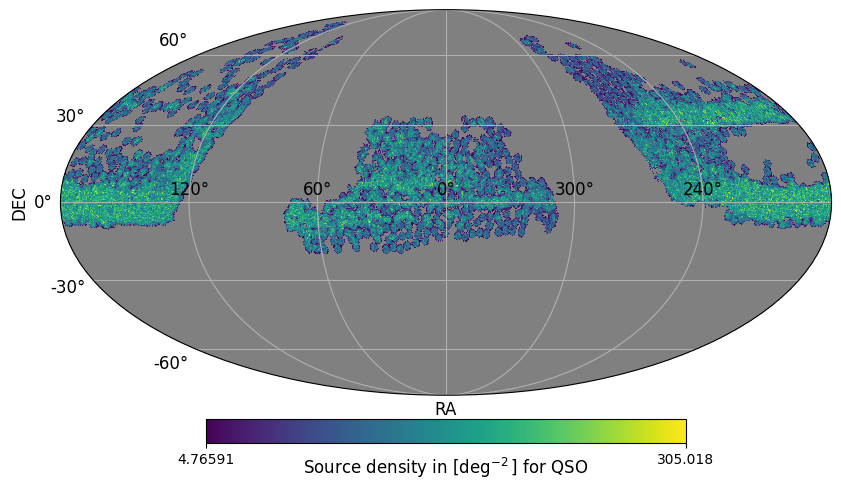

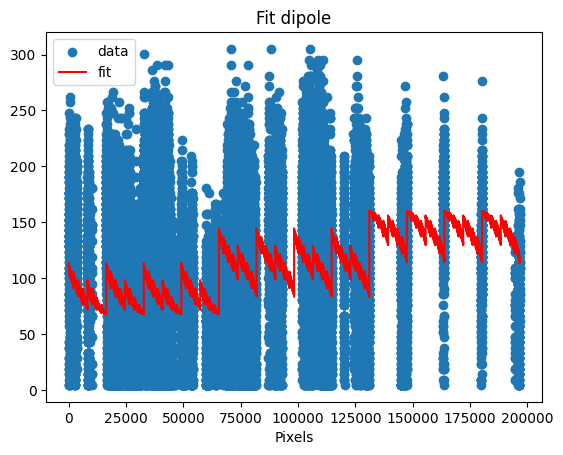

In [5]:
init =  (200, 1, 100, 40)
m = ALL_Mapper.fit_dipole("Masked", init, weights=DR1_Mapper.FRACCOVnside)
m

### From simulation

Total number of sources in the entire sky : 12386304
Theorical number of sources in one pixel : 63


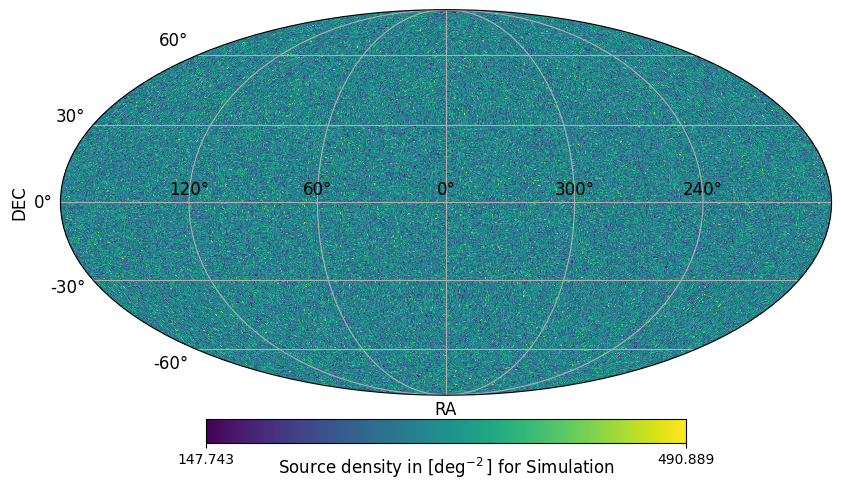

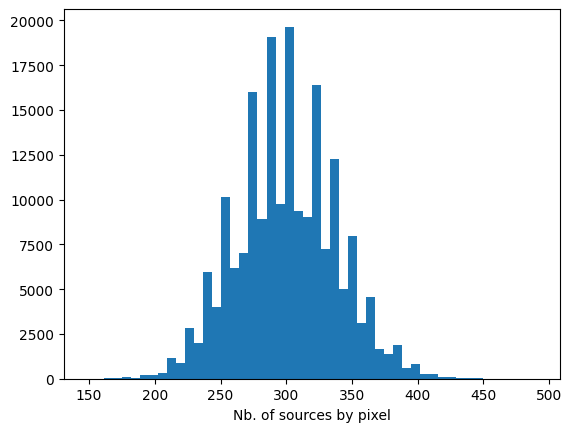

In [6]:
NSource_px_th = int(ALL_Mapper.map.max() * ALL_Mapper.area_deg2)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

#data = generate_lumMag(NSource_px_th*npix, to_table=True)
data = {}
data["RA"], data["DEC"] = generate_raDec(NSource_px_th*npix)
data = Table(data)

simu_Mapper = DensityMapper(data, nside=nside)
simu_Mapper._set_suffixTextPlot(unit = "Simulation") #to customize the unit of plots.
simu_Mapper.plot('')

get_hist(simu_Mapper.map, bins=50);

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.321e+05 (χ²/ndof = 1.2)  │              Nfcn = 661              │
│ EDM = 8.31e-06 (Goal: 0.0002)    │           time = 20.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  295.43   │   0.10    │   -0.10    │    0.10    │    0    │         │       │
│ 1 │ A    │  2.2e-3   │  0.8e-3   │  -0.7e-3   │   0.8e-3   │    0    │    1    │       │
│ 2 │ ra   │    105    │    14     │    -14     │     15     │    0    │   360   │       │
│ 3 │ dec  │    44     │    19     │    -23     │     16     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.1    │    0.1    │  -0.7e-3  │  0.8e-3   │    -14    │    15     │    -23    │    16     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────┐
│     │          M          A         ra        dec │
├─────┼─────────────────────────────────────────────┤
│   M │     0.0104   -42.9e-6      0.156     -1.080 │
│   A │   -42.9e-6    5.7e-07 -2.7561e-3  7.9424e-3 │
│  ra │      0.156 -2.7561e-3        191    -0.06e3 │
│ dec │     -1.080  7.9424e-3    -0.06e3        350 │
└─────┴─────────────────────────────────────────────┘

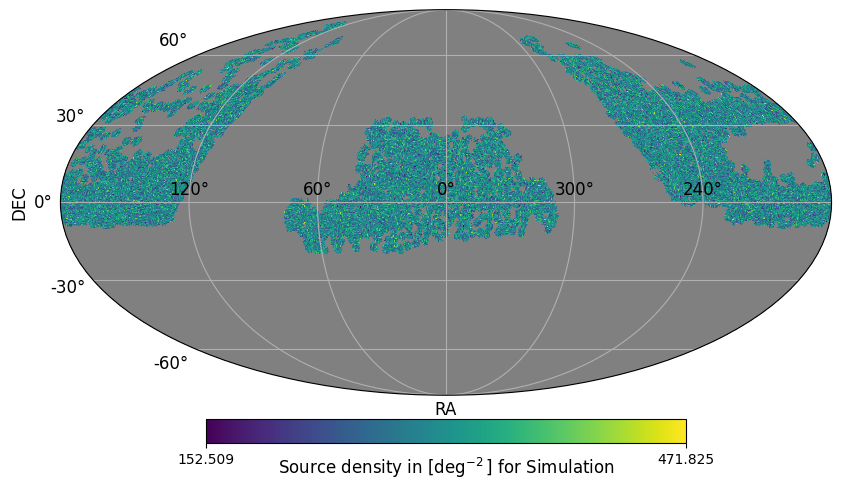

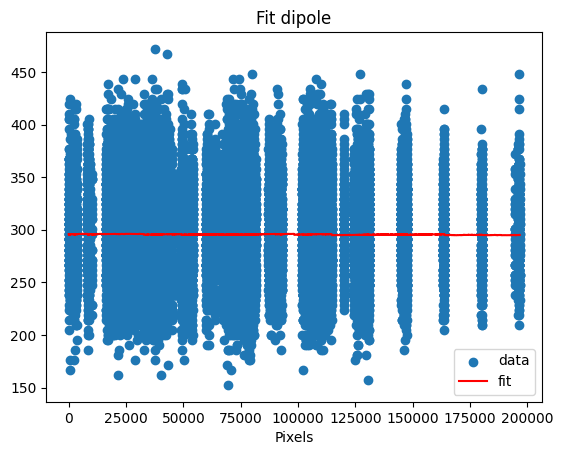

In [7]:
simu_Mapper.set_mask(mask=ALL_Mapper.mapMasked.mask)

init =  (200, 0, 100, 40)
m = simu_Mapper.fit_dipole("Masked", init)
m

### FRACCOV rescaling

Saving DESI_DR1_QSO_Simul_Density_map_mask0 in data/Data DESI/DESI Figures/DESI DR1 QSO/DESI_DR1_QSO_Simul/DESI_DR1_QSO_Simul_Density_map_mask0.pdf


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.184e+06 (χ²/ndof = 21.3) │              Nfcn = 507              │
│ EDM = 3.23e-06 (Goal: 0.0002)    │           time = 15.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │   48.19   │   0.04    │   -0.04    │    0.04    │    0    │         │       │
│ 1 │ A    │  0.8356   │  0.0014   │  -0.0014   │   0.0014   │    0    │    1    │       │
│ 2 │ ra   │  195.42   │   0.21    │   -0.21    │    0.21    │    0    │   360   │       │
│ 3 │ dec  │  -69.11   │   0.05    │   -0.05    │    0.05    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.04   │   0.04    │  -0.0014  │  0.0014   │   -0.21   │   0.21    │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │        M        A       ra      dec │
├─────┼─────────────────────────────────────┤
│   M │  0.00157  27.5e-6  -0.0004  -0.0005 │
│   A │  27.5e-6 2.05e-06   5.1e-6 -12.3e-6 │
│  ra │  -0.0004   5.1e-6   0.0461   0.0028 │
│ dec │  -0.0005 -12.3e-6   0.0028  0.00288 │
└─────┴─────────────────────────────────────┘

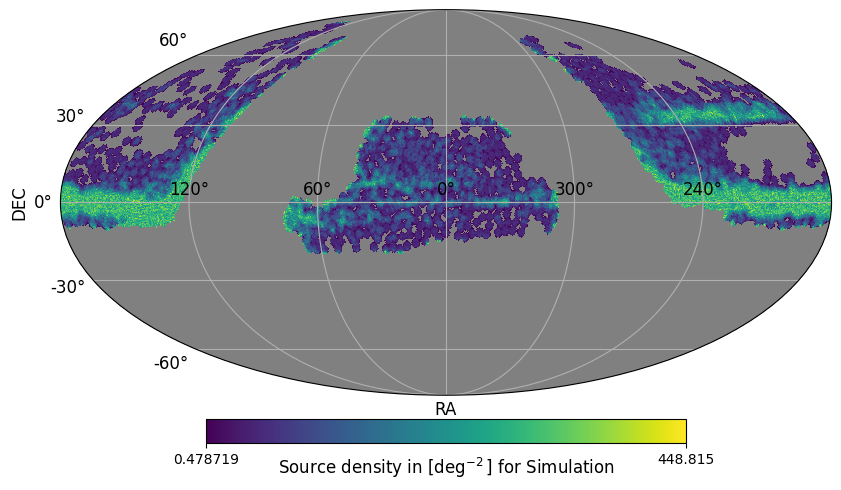

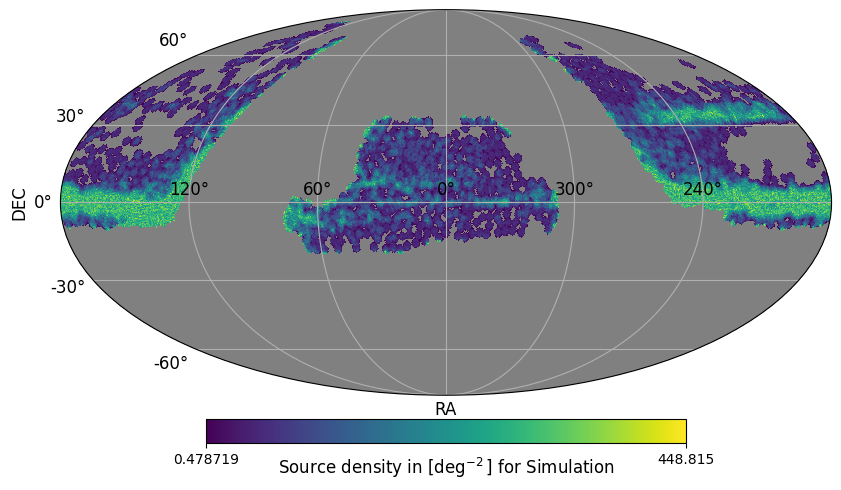

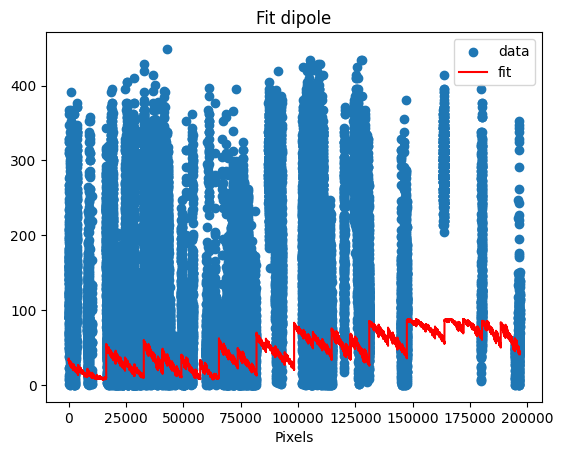

In [8]:
hpmap = simu_Mapper.map * DR1_Mapper.FRACCOVnside.filled(0)
hpmap[np.isnan(hpmap)] = 0
simu_Mapper_scale = DensityMapper.from_map(hpmap)
simu_Mapper_scale._set_suffixTextPlot(unit = "Simulation") #to customize the unit of plots.
simu_Mapper_scale.set_mask()
# simu_Mapper_scale.plot("Masked")
# get_savefig(plt, output_path_Simu, suffix_Simu+"mask0");

init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Masked", init)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.166e+06 (χ²/ndof = 5.9)  │              Nfcn = 401              │
│ EDM = 9.49e-07 (Goal: 0.0002)    │           time = 11.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  146.55   │   0.10    │   -0.10    │    0.10    │    0    │         │       │
│ 1 │ A    │  0.8780   │  0.0014   │  -0.0014   │   0.0014   │    0    │    1    │       │
│ 2 │ ra   │  185.13   │   0.15    │   -0.15    │    0.15    │    0    │   360   │       │
│ 3 │ dec  │  -65.93   │   0.06    │   -0.06    │    0.06    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.1    │    0.1    │  -0.0014  │  0.0014   │   -0.15   │   0.15    │   -0.06   │   0.06    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │  0.00988  46.5e-6    0.001  -0.0025 │
│   A │  46.5e-6 2.02e-06  27.8e-6 -33.8e-6 │
│  ra │    0.001  27.8e-6   0.0231  -0.0011 │
│ dec │  -0.0025 -33.8e-6  -0.0011  0.00313 │
└─────┴─────────────────────────────────────┘

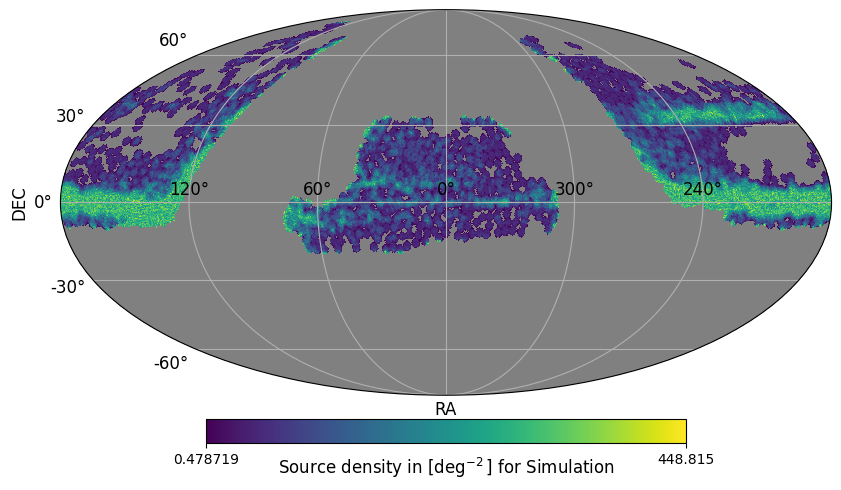

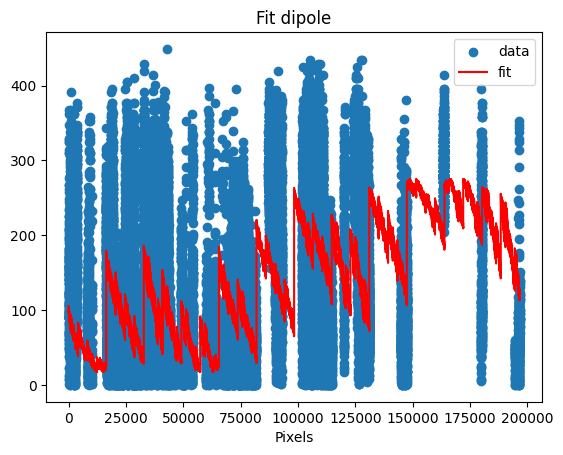

In [12]:
init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Masked", init, weights=DR1_Mapper.FRACCOVnside, names=names)
m

### From Poisson noise

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.161e+06 (χ²/ndof = 21.2) │              Nfcn = 467              │
│ EDM = 3.22e-06 (Goal: 0.0002)    │           time = 13.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │   48.33   │   0.04    │   -0.04    │    0.04    │    0    │         │       │
│ 1 │ A    │  0.8314   │  0.0014   │  -0.0014   │   0.0014   │    0    │    1    │       │
│ 2 │ ra   │  194.52   │   0.21    │   -0.21    │    0.21    │    0    │   360   │       │
│ 3 │ dec  │  -68.95   │   0.05    │   -0.05    │    0.05    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.04   │   0.04    │  -0.0014  │  0.0014   │   -0.21   │   0.21    │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │        M        A       ra      dec │
├─────┼─────────────────────────────────────┤
│   M │  0.00157  27.7e-6  -0.0004  -0.0005 │
│   A │  27.7e-6 2.05e-06   6.1e-6 -12.7e-6 │
│  ra │  -0.0004   6.1e-6   0.0459   0.0027 │
│ dec │  -0.0005 -12.7e-6   0.0027  0.00289 │
└─────┴─────────────────────────────────────┘

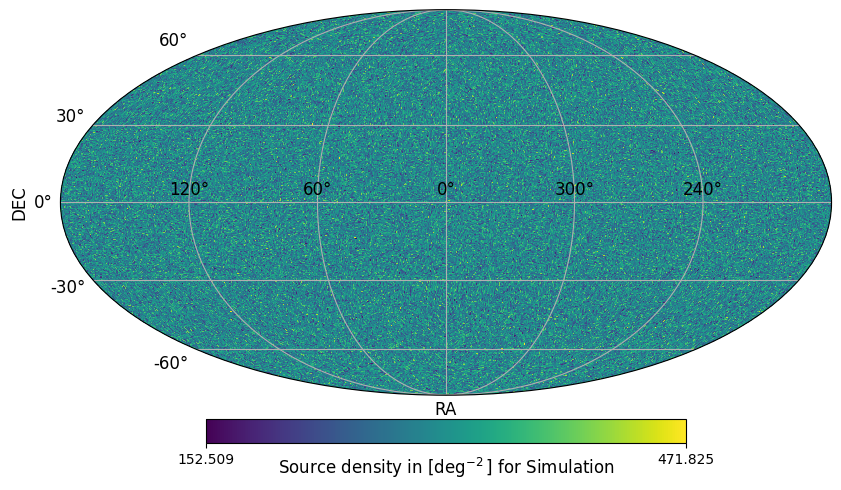

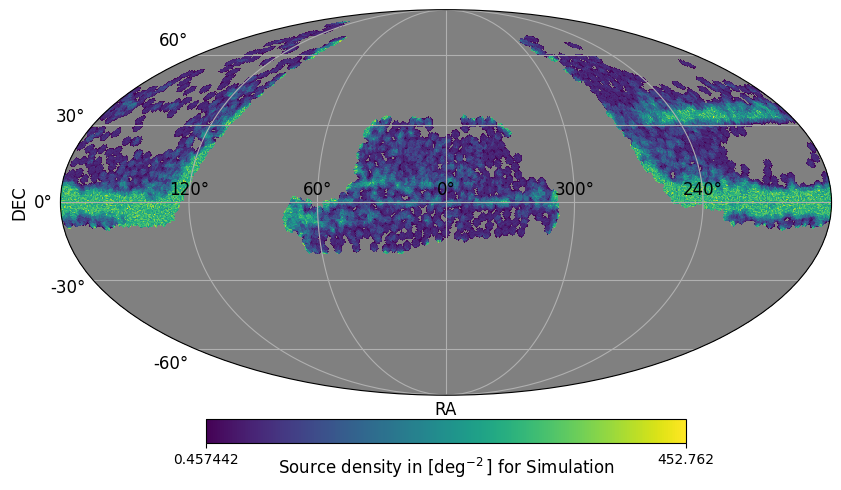

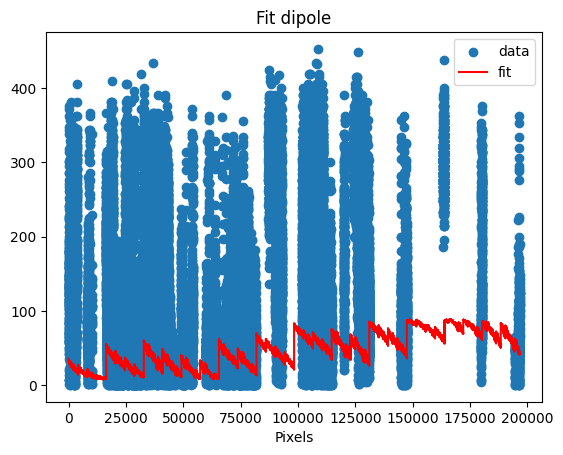

In [31]:
hpmap = np.random.poisson(NSource_px_th, npix)/area_deg2
simu_Mapper_pois = DensityMapper.from_map(hpmap)
simu_Mapper_pois._set_suffixTextPlot(unit = "Simulation") #to customize the unit of plots.
simu_Mapper_pois.plot('')

hpmap = simu_Mapper_pois.map * DR1_Mapper.FRACCOVnside.filled(0)
hpmap[np.isnan(hpmap)] = 0
simu_Mapper_pois = DensityMapper.from_map(hpmap)
simu_Mapper_pois._set_suffixTextPlot(unit = "Simulation") #to customize the unit of plots.
simu_Mapper_pois.set_mask()

init =  (200, 0, 100, 40)
m = simu_Mapper_pois.fit_dipole("Masked", init)
m

## FRACCOV cut

### From QSO

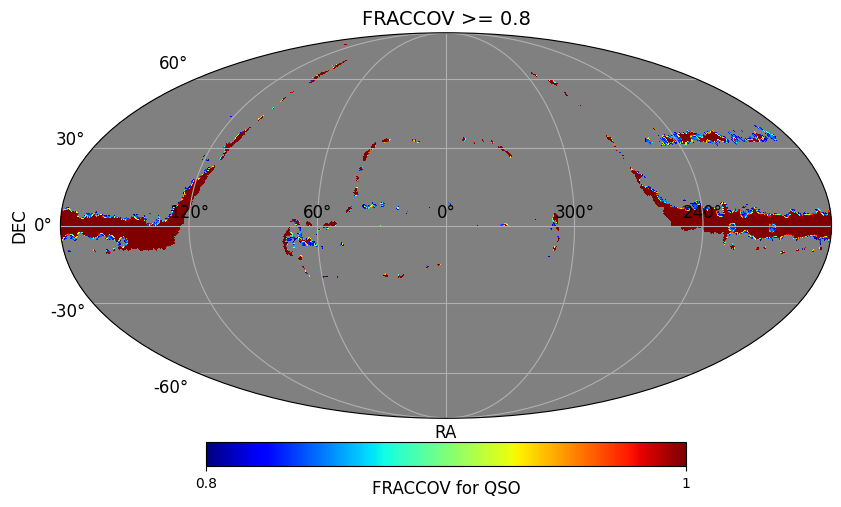

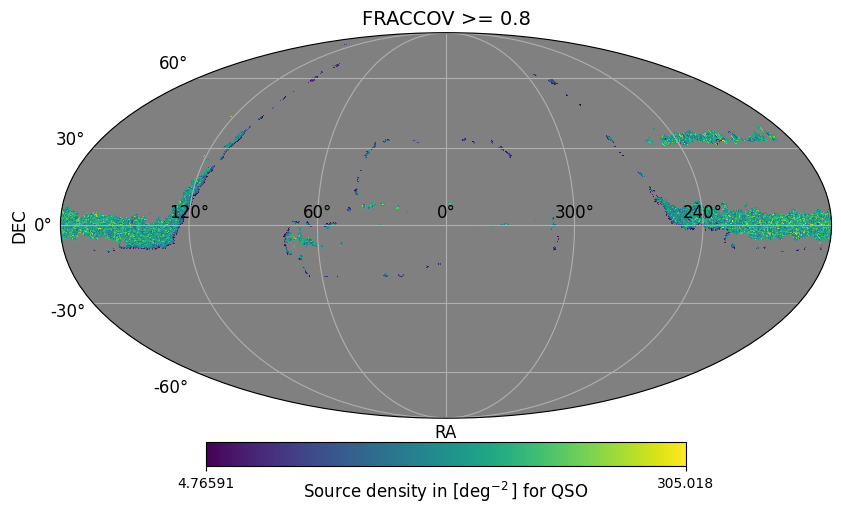

In [13]:
frac_min = 0.8
title = f'FRACCOV >= {frac_min}'

DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title=title)

ALL_Mapper.set_cutMask(DR1_Mapper.FRACCOVcut.mask)
ALL_Mapper.plot(use_map='Cut', title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.933e+05 (χ²/ndof = 2.0)  │              Nfcn = 877              │
│ EDM = 0.000498 (Goal: 0.0002)    │           time = 38.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  121.10   │   0.05    │   -0.05    │    0.05    │    0    │         │       │
│ 1 │ A    │  0.4507   │  0.0015   │  -0.0015   │   0.0015   │    0    │    1    │       │
│ 2 │ ra   │   0.004   │  180.354  │   -0.004   │  180.354   │    0    │   360   │       │
│ 3 │ dec  │-89.9999999977│0.0324589096│-0.0000000023│0.0324589096│   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.05   │   0.05    │  -0.0015  │  0.0015   │  -0.004   │  180.354  │  -2.3e-9  │32458909.6e-9│
│  Valid   │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   True    │   True    │   False   │   True    │   False   │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────┐
│     │               M               A              ra             dec │
├─────┼─────────────────────────────────────────────────────────────────┤
│   M │         0.00293          4.8e-6          0.0676         0.20e-9 │
│   A │          4.8e-6        2.19e-06      -8.6781e-3        -0.03e-9 │
│  ra │          0.0676      -8.6781e-3        3.41e+07 100.85124782e-3 │
│ dec │         0.20e-9        -0.03e-9 100.85124782e-3        2.99e-10 │
└─────┴─────────────────────────────────────────────────────────────────┘

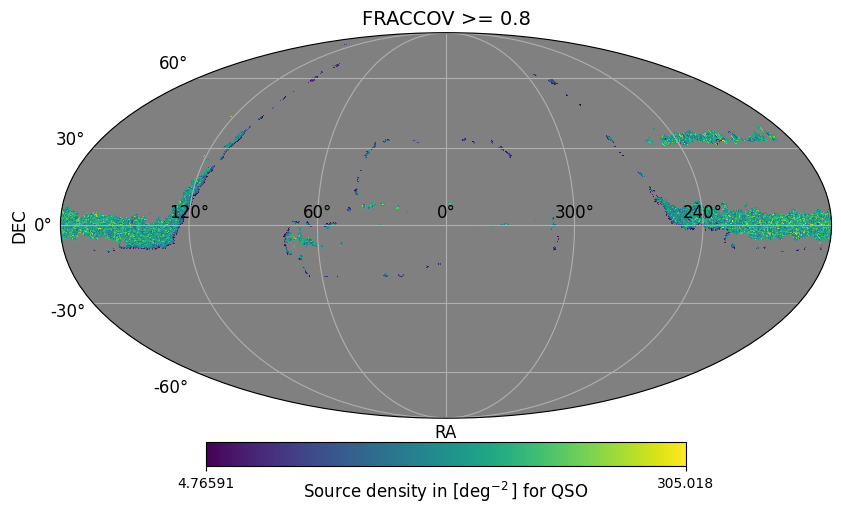

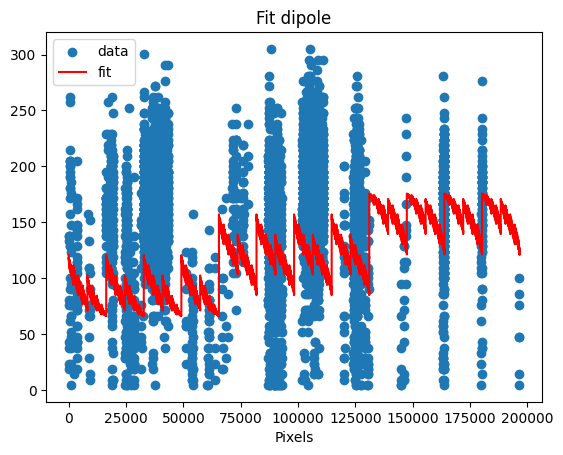

In [14]:
init =  (200, 0, 100, 40)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title)
m

### From simulation

Attribut FRACCOVcut already existed and has been replaced.


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.454e+04 (χ²/ndof = 0.3)  │              Nfcn = 614              │
│ EDM = 6.69e-08 (Goal: 0.0002)    │           time = 26.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  285.10   │   0.18    │   -0.18    │    0.18    │    0    │         │       │
│ 1 │ A    │  2.6e-12  │58708130.2e-12│  -2.6e-12  │58708130.2e-12│    0    │    1    │       │
│ 2 │ ra   │   358.9   │   297.8   │   -358.9   │    1.1     │    0    │   360   │       │
│ 3 │ dec  │   89.4    │   158.1   │   -158.1   │    0.6     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.18   │   0.18    │ -2.6e-12  │58708130.2e-12│  -358.9   │    1.1    │  -158.1   │    0.6    │
│  Valid   │   False   │   False   │   True    │   False   │   True    │   True    │   False   │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   True    │   True    │   False   │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   True    │   False   │   False   │   True    │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────┐
│     │            M            A           ra          dec │
├─────┼─────────────────────────────────────────────────────┤
│   M │       0.0311    865.0e-15        0.000        0.000 │
│   A │    865.0e-15        6e-16  92.9401e-12 3.5715825e-9 │
│  ra │        0.000  92.9401e-12     1.53e+03            0 │
│ dec │        0.000 3.5715825e-9            0          454 │
└─────┴─────────────────────────────────────────────────────┘

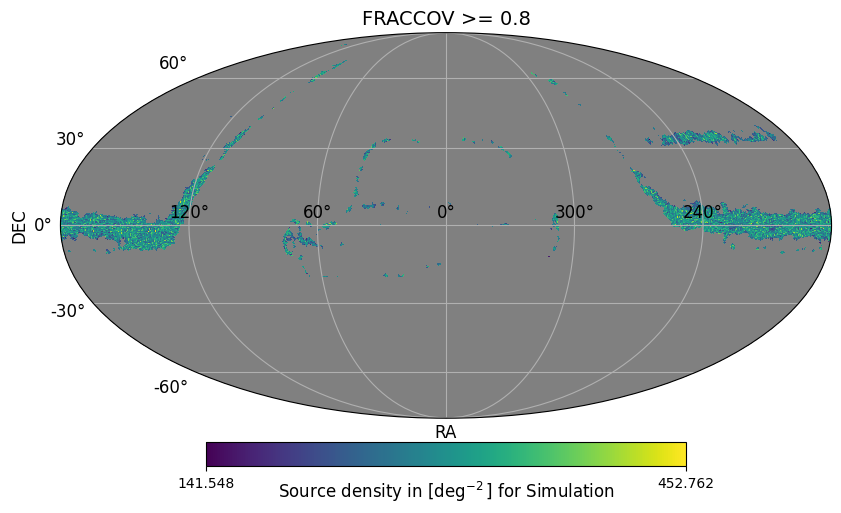

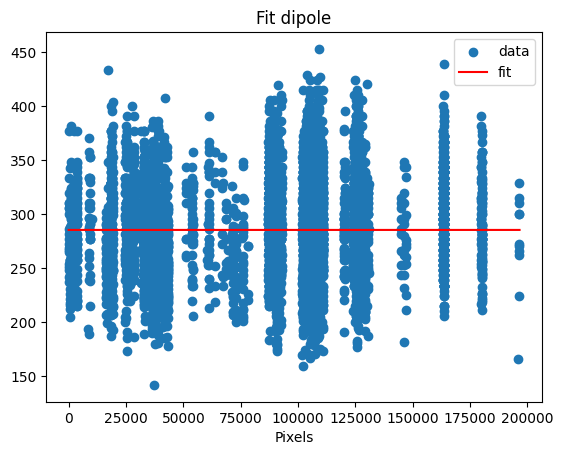

In [15]:
frac_min = 0.8
title = f'FRACCOV >= {frac_min}'
DR1_Mapper.cut_FracCov(frac_min=frac_min)
simu_Mapper_scale.set_cutMask(DR1_Mapper.FRACCOVcut.mask)

init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title)
m

## Density count > min and FRACCOV > 0.9

### From QSO

Attribut FRACCOVcut already existed and has been replaced.
Attribut map has no attribut mask. Using mask from mapMasked instead.
Attribut mapCut already existed and has been replaced.
Attribut mapCut already existed and has been replaced.


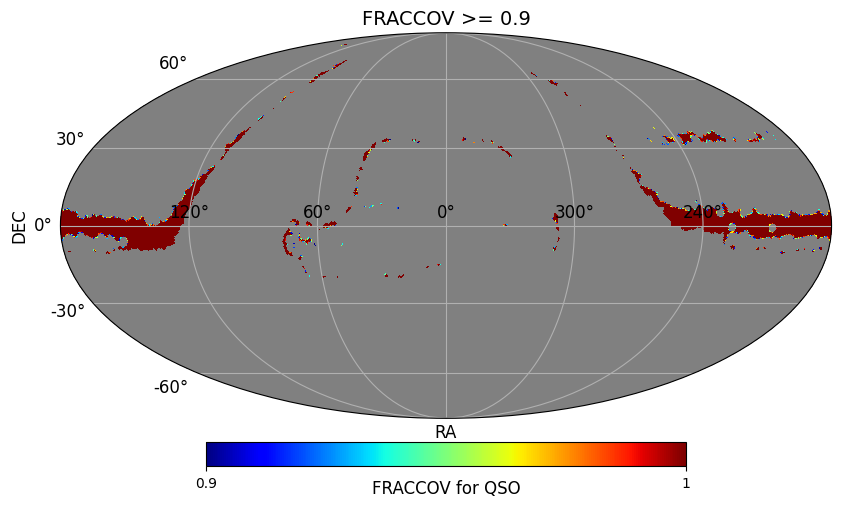

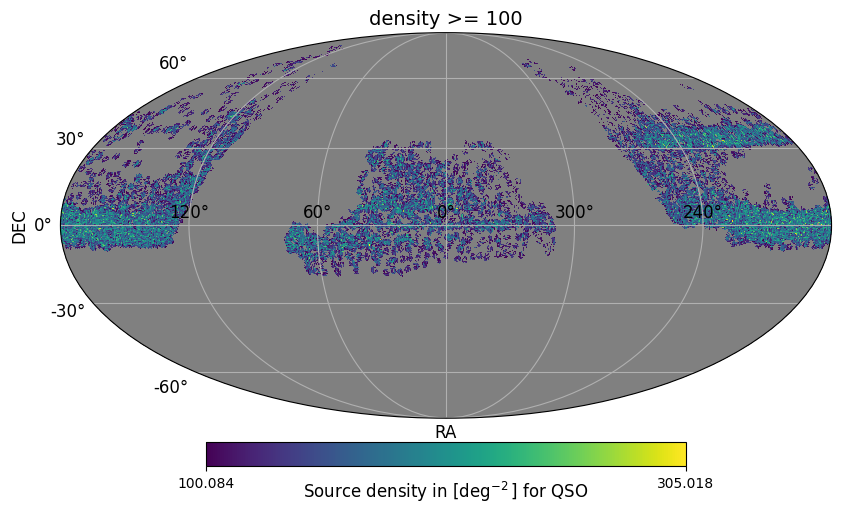

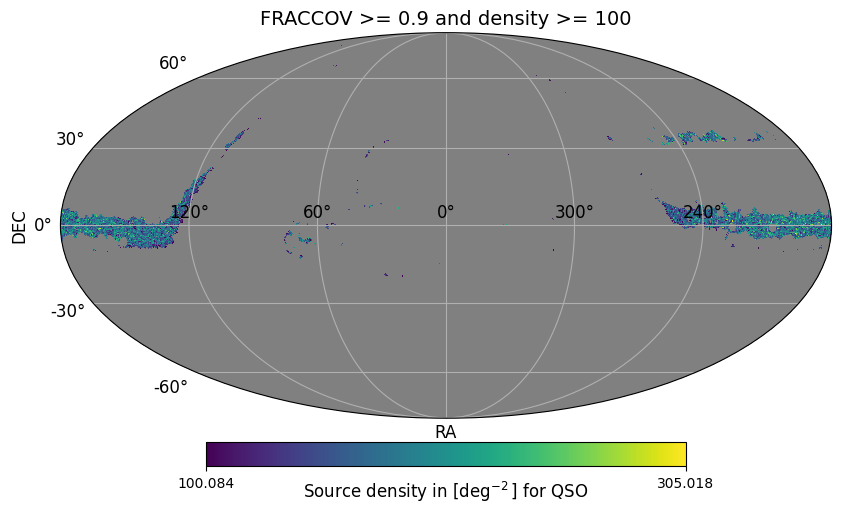

In [16]:
frac_min = 0.9
DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title = f"FRACCOV >= {frac_min}")

count_min = 100
ALL_Mapper.select_bounds(map_min=count_min)
ALL_Mapper.plot(use_map="Cut", title = f"density >= {count_min}")

title = f'FRACCOV >= {frac_min} and density >= {count_min}'
ALL_Mapper.set_cutMask(DR1_Mapper.FRACCOVcut.mask, fromMap="Cut")
ALL_Mapper.plot(use_map="Cut", title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.263e+04 (χ²/ndof = 0.2)  │              Nfcn = 865              │
│ EDM = 3.52e-05 (Goal: 0.0002)    │           time = 41.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  166.44   │   0.16    │   -0.16    │    0.16    │    0    │         │       │
│ 1 │ A    │  1.6e-9   │54139.6e-9 │  -1.6e-9   │ 54139.6e-9 │    0    │    1    │       │
│ 2 │ ra   │  0.01e3   │  0.33e3   │  -0.33e3   │   0.33e3   │    0    │   360   │       │
│ 3 │ dec  │    -50    │    90     │    -90     │     90     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.16   │   0.16    │  -1.6e-9  │54139.6e-9 │  -0.33e3  │  0.33e3   │    -90    │    90     │
│  Valid   │   False   │   False   │   True    │   False   │   False   │   False   │   False   │   False   │
│ At Limit │   False   │   False   │   True    │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   True    │   True    │   True    │   True    │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────┐
│     │              M              A             ra            dec │
├─────┼─────────────────────────────────────────────────────────────┤
│   M │         0.0265      78.42e-12         -0.000         -0.001 │
│   A │      78.42e-12       3.45e-13  -157.24934e-9 -4.37005674e-6 │
│  ra │         -0.000  -157.24934e-9       1.15e+04              0 │
│ dec │         -0.001 -4.37005674e-6              0       2.26e+04 │
└─────┴─────────────────────────────────────────────────────────────┘

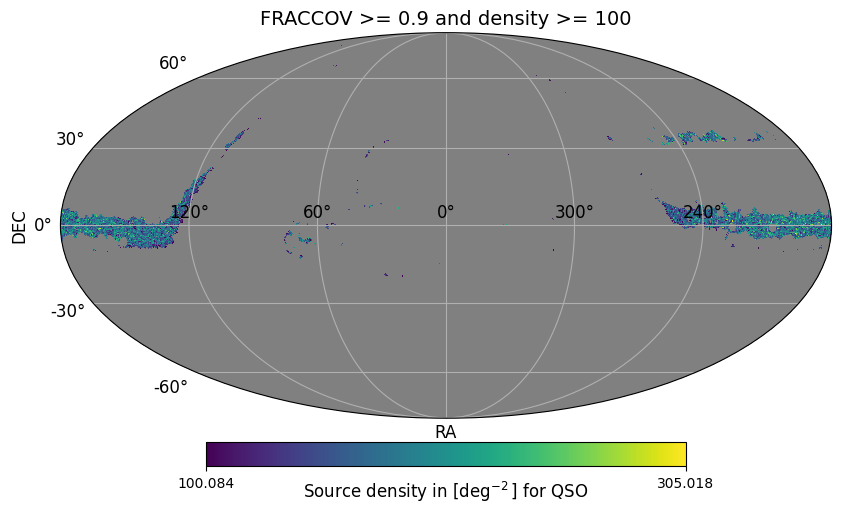

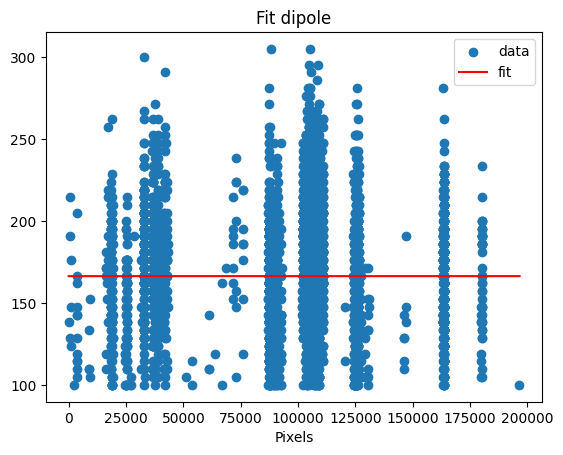

In [17]:
init =  (200, 0, 100, 40)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title)
m

### From simulation

Attribut FRACCOVcut already existed and has been replaced.
Attribut map has no attribut mask. Using mask from mapMasked instead.
Attribut mapCut already existed and has been replaced.
Attribut mapCut already existed and has been replaced.


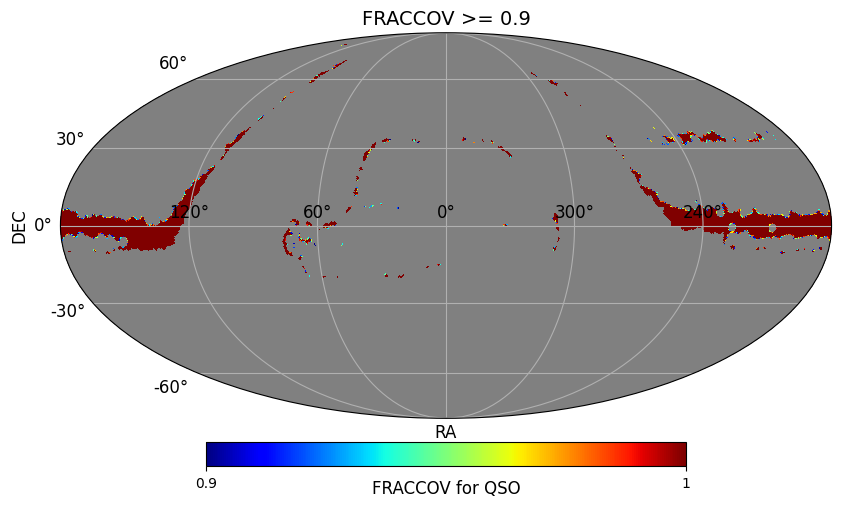

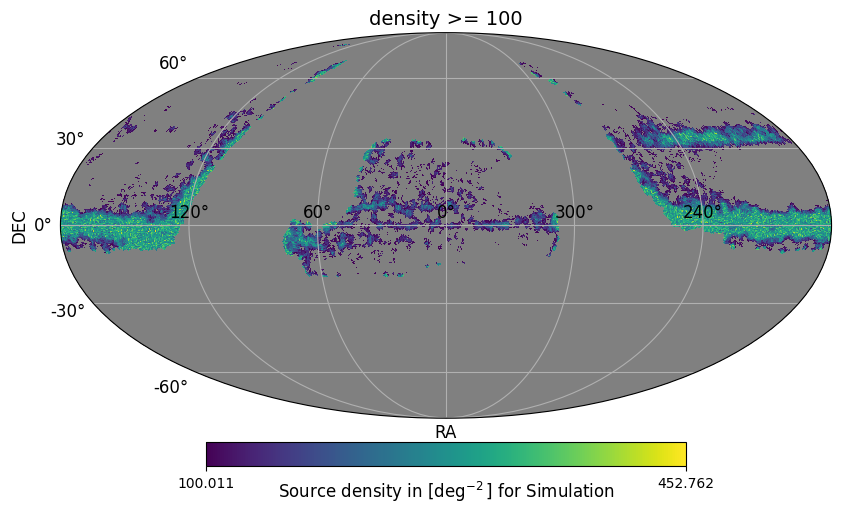

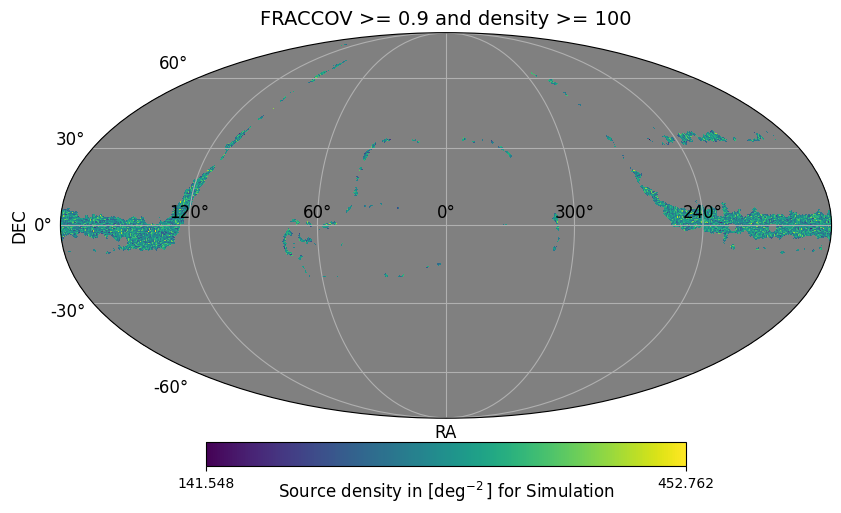

In [18]:
frac_min = 0.9
DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title = f"FRACCOV >= {frac_min}")

count_min = 100
simu_Mapper_scale.select_bounds(map_min=count_min)
simu_Mapper_scale.plot(use_map="Cut", title = f"density >= {count_min}")

title = f'FRACCOV >= {frac_min} and density >= {count_min}'
simu_Mapper_scale.set_cutMask(DR1_Mapper.FRACCOVcut.mask, fromMap="Cut")
simu_Mapper_scale.plot(use_map="Cut", title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.709e+04 (χ²/ndof = 0.2)  │              Nfcn = 600              │
│ EDM = 5.01e-06 (Goal: 0.0002)    │           time = 18.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │   294.1   │    0.2    │    -0.2    │    0.2     │    0    │         │       │
│ 1 │ A    │  0.06e-9  │506835.80e-9│  -0.06e-9  │506835.80e-9│    0    │    1    │       │
│ 2 │ ra   │  0.19e3   │  0.27e3   │  -0.19e3   │   0.17e3   │    0    │   360   │       │
│ 3 │ dec  │    85     │    164    │    -164    │     5      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.2    │    0.2    │ -0.06e-9  │506835.80e-9│  -0.19e3  │  0.17e3   │   -164    │     5     │
│  Valid   │   False   │   False   │   True    │   False   │   True    │   True    │   False   │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   True    │   True    │   False   │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   True    │   False   │   False   │   True    │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────┐
│     │             M             A            ra           dec │
├─────┼─────────────────────────────────────────────────────────┤
│   M │        0.0387   -126.53e-12         -0.00          0.00 │
│   A │   -126.53e-12      1.15e-13 1.09118340e-6 -497.16363e-9 │
│  ra │         -0.00 1.09118340e-6      1.29e+05          -0e3 │
│ dec │          0.00 -497.16363e-9          -0e3      3.59e+03 │
└─────┴─────────────────────────────────────────────────────────┘

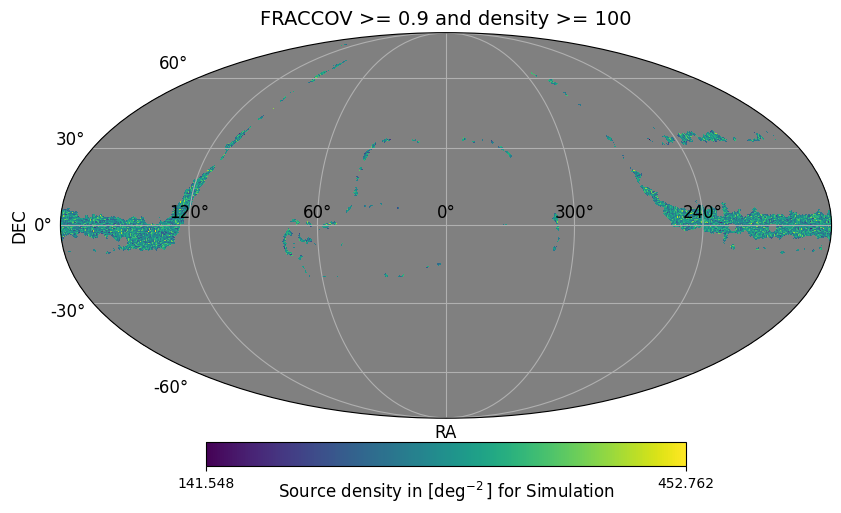

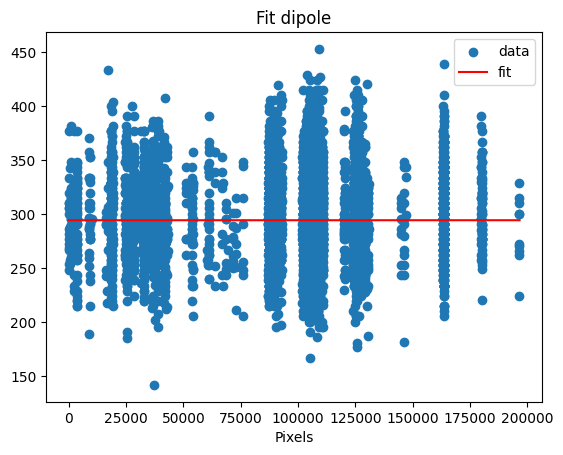

In [19]:
init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title)
m

## Introducing clustering

In [33]:
DIRcl = "Simulation/Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
FILEcl = DIRcl + sufix + '.fits'

data = fitsio.FITS(FILEcl)
data


  file: Simulation/Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_tests_fit.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS
  2      BINARY_TBL      FIT_NUMPY
  3      BINARY_TBL      FIT_MINUIT

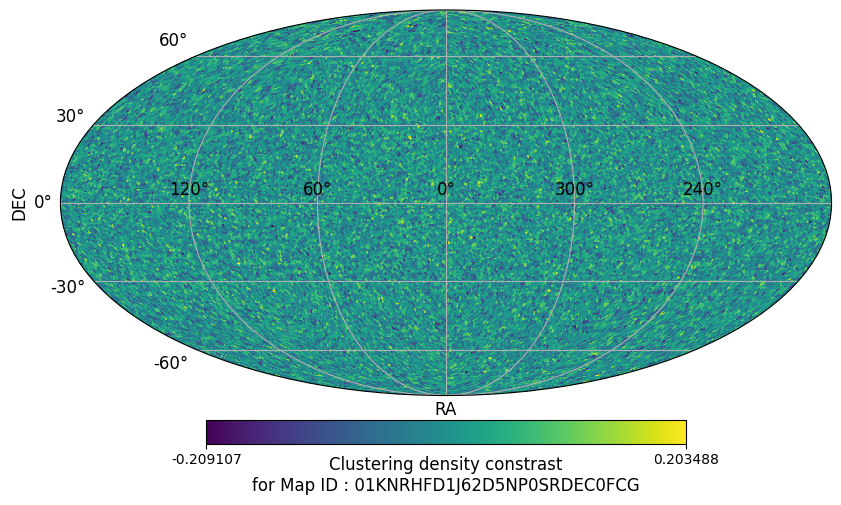

In [56]:
from Simulation.mappers import CountMapper

mapID, hpmap = data['MAPS'][0] #first clustering map
clMapper = CountMapper.from_map(hpmap)
clMapper._set_instance_settingsPlot(unit = f"Clustering density constrast\nfor Map ID : {mapID}")
clMapper.plot()

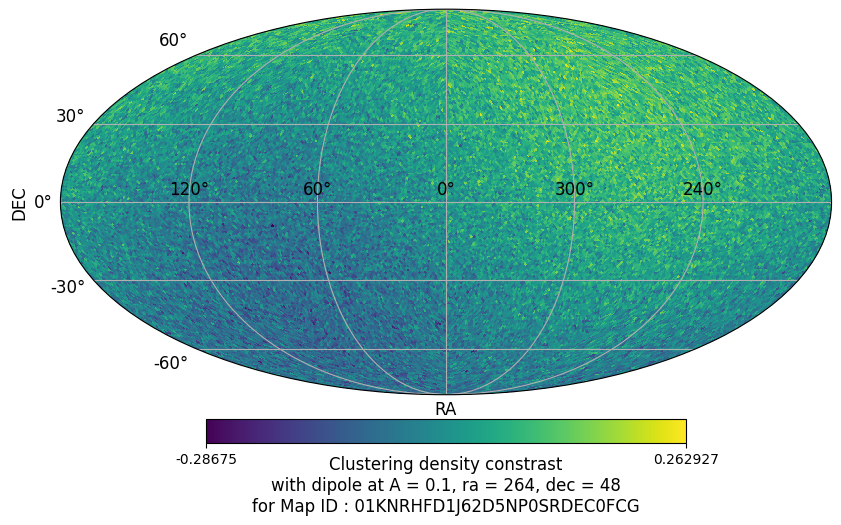

In [54]:
A, ra, dec = 0.1, 264, 48
clDipole = apply_dipole_MD(clMapper.map, clMapper.map, A, ra, dec, nest=True)
clDipoleMapper = CountMapper.from_map(clDipole)
clDipoleMapper._set_instance_settingsPlot(unit = f"Clustering density constrast\nwith dipole at A = {A}, ra = {ra}, dec = {dec}\nfor Map ID : {mapID}")
clDipoleMapper.plot()

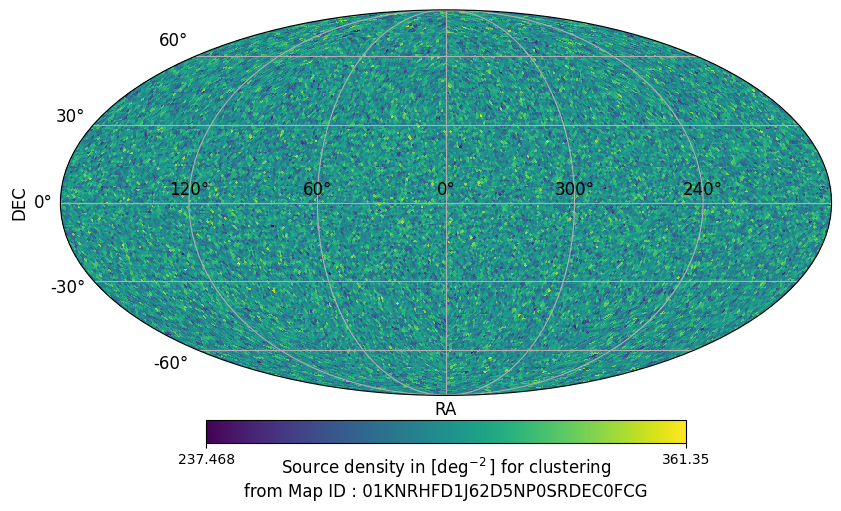

In [59]:
clMonop = apply_monopole_Mcontrast(clMapper.map, NSource_px_th/area_deg2)
clMonopMapper = DensityMapper.from_map(clMonop)
clMonopMapper._set_suffixTextPlot(unit = f"clustering\nfrom Map ID : {mapID}")
clMonopMapper.plot()

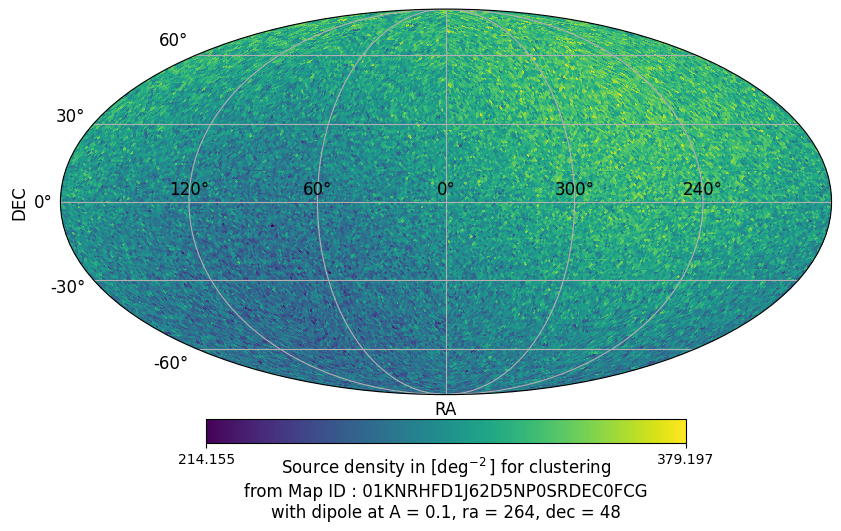

In [60]:
clDipMonop = apply_monopole_Mcontrast(clDipoleMapper.map, NSource_px_th/area_deg2)
clDipMonopMapper = DensityMapper.from_map(clDipMonop)
clDipMonopMapper._set_suffixTextPlot(unit = f"clustering\nfrom Map ID : {mapID}\nwith dipole at A = {A}, ra = {ra}, dec = {dec}")
clDipMonopMapper.plot()